# **05_matriz_9box**

## Objetivo

Identificar colaboradores com maior potencial e desempenho dentro da organização, avaliando também a relação desses grupos com o turnover.

---

### Perguntas e valores análisados

- Quais colaboradores possuem alto potencial e alto desempenho?
- Existem talentos estratégicos sendo desligados?
- Quais quadrantes da Matriz 9 Box apresentam maior taxa de turnover?
- A empresa está conseguindo reter seus principais talentos?
- Conclusão

---

# Código


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")
df = pd.read_csv('../data/tabela_base_traduzida.csv')


### **Construção dos Scores**

Para representar a lógica da Matriz 9 Box será criado: Score de Potencial e Score de Desempenho


In [4]:
# Score responsável por repreasentar o potencial de crescimento do colaborador
df["Score_Potencial"] = (
    df["Escolaridade"] +
    df["Satisfação_geral"]
)

# Score responsável por representar o desempenho do colaborador

df["Score_Desempenho"] = (
    df["Razão_salarial"] +
    df["Nivel_do_Cargo"]
)

df[["Score_Potencial", "Score_Desempenho"]].head()

,Score_Potencial,Score_Desempenho
0,10,3.085088
1,13,3.267628
2,14,4.111450
3,17,3.235452
4,11,2.875124


### **Classificação dos Colaboradores**

In [5]:
# Divide os colaboradores em três grupos usando os tercis da distribuição

df["Potencial"] = pd.qcut(
    df["Score_Potencial"],
    q = 3,
    labels = ["Baixo", "Médio", "Alto"]
)

df["Desempenho"] = pd.qcut(
    df["Score_Desempenho"],
    q = 3,
    labels = ["Baixo", "Médio", "Alto"]
)

df[["Potencial", "Desempenho"]].head()

,Potencial,Desempenho
0,Baixo,Baixo
1,Baixo,Médio
2,Médio,Alto
3,Alto,Baixo
4,Baixo,Baixo


### **Matriz 9 Box**

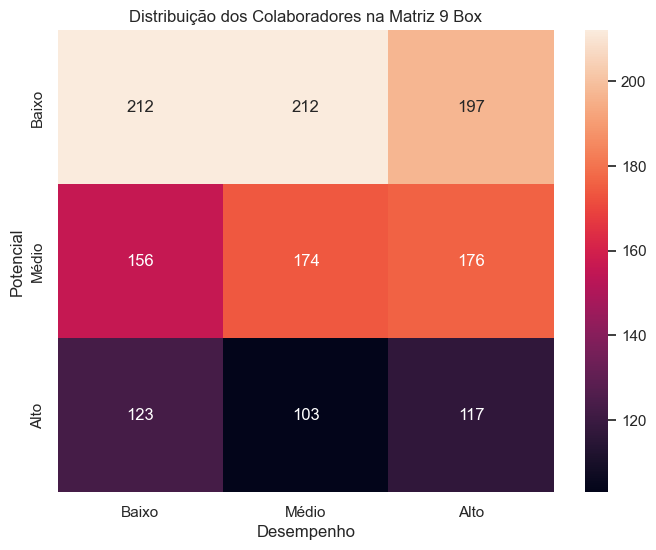

In [8]:
matriz_9box = pd.crosstab(
    df["Potencial"],
    df["Desempenho"]
)

plt.figure(figsize = (8, 6))

sns.heatmap(
    matriz_9box,
    annot = True,
    fmt = "d"
)

plt.title("Distribuição dos Colaboradores na Matriz 9 Box")
plt.xlabel("Desempenho")
plt.ylabel("Potencial")

plt.show()

### **Taxa de Turnover por Quadranrte**

C:\Users\Igor Cruz\AppData\Local\Temp\ipykernel_40676\3949173383.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  turnover_9box = (df.groupby(["Potencial", "Desempenho"])["Evento"].mean().mul(100).round(2).reset_index())


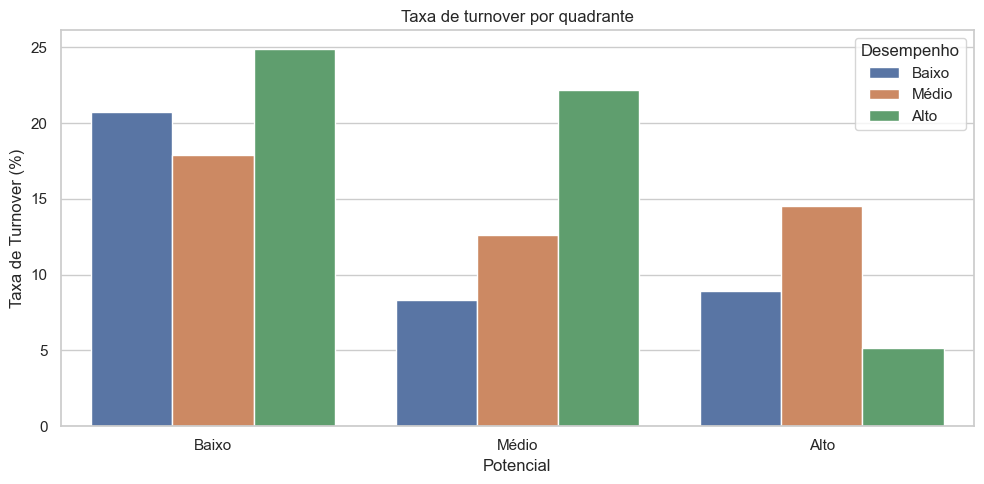

In [14]:
# Calcula a porcentagem de desligamentos em cada parte do quadrante

df["Evento"] = df["Demitido"].map({ "No": 0, "Yes": 1})

turnover_9box = (df.groupby(["Potencial", "Desempenho"])["Evento"].mean().mul(100).round(2).reset_index())

plt.figure(figsize = (10, 5))

sns.barplot(data = turnover_9box, x = "Potencial", y = "Evento", hue = "Desempenho")

plt.title("Taxa de turnover por quadrante")
plt.xlabel("Potencial")
plt.ylabel("Taxa de Turnover (%)")

plt.tight_layout()
plt.show()

### **Talentos Estratégicos Perdidos**

In [24]:
# Colaboradores classificados com alto potencial e alto desempenho e que foram desligados da empresa

talentos_perdidos = df[
    (df["Potencial"] == "Alto") &
    (df["Desempenho"] == "Alto") &
    (df["Demitido"] == "Yes")
]

print(f"Total de talentos estratégicos perdidos: {talentos_perdidos.shape[0]}")

Total de talentos estratégicos perdidos: 6


In [25]:
talentos_perdidos.head()

,ID_Funcionario,Demitido,Idade,Faixa_Etaria,Genero,Estado_Civil,Maior_de_18,Distancia_de_Casa,Faixa_Distancia_de_Casa,Escolaridade,...,Anos_no_Cargo_Atual,Anos_Desde_Ultima_Promocao,Anos_com_Gerente_Atual,Contagem_de_Funcionarios,Horas_Padrao,Score_Potencial,Score_Desempenho,Potencial,Desempenho,Evento
33,42,Yes,39,Adulto,Male,Married,Y,5,Muito próxima,3,...,0,0,0,1,80,18,5.117417,Alto,Alto,1
385,514,Yes,30,Adulto,Male,Single,Y,4,Muito próxima,3,...,0,0,0,1,80,16,3.845922,Alto,Alto,1
595,825,Yes,58,Maduro,Male,Single,Y,2,Muito próxima,4,...,15,13,8,1,80,17,5.337885,Alto,Alto,1
776,1077,Yes,20,Jovem,Female,Single,Y,9,Próxima,3,...,2,0,2,1,80,16,3.799368,Alto,Alto,1
946,1318,Yes,40,Adulto,Male,Single,Y,25,Muito distantew,4,...,4,1,0,1,80,16,3.715079,Alto,Alto,1


## **Conclusão**

A aplicação de Ciência de Dados e de modeloss estatísticos neste projeto permitiu transformar dados de RH em um framework preditivo e estratégico para a tomada de decisão. Ao cruzar a modelagem estatística com as práticas de gestão de pessoas, conseguimos atingir os seguintes objetivos:

### **Principais Pontos**

- **Mapeamento de Potencial e Desempenho:** Conseguimos segmentar claramente a força de trabalho, identificando os colaboradores com maior potencial de crescimento e alta performance.

- **Diagnóstico da Matriz 9-Box:** A estruturação automatizada da matriz forneceu uma visão clara sobre a distribuição real dos talentos dentro da organização.

- **Padrões de Turnover por Quadrante:** Identificamos quais quadrantes específicos da matriz concentram as maiores taxas de desligamento, permitindo que o RH deixe de ser reativo e passe a agir de forma preventiva.

- **Mitigação de Risco de Talentos Estratégicos:** Conseguimos isolar e identificar os profissionais de alto valor e sucessores críticos que estavam com o maior risco de evasão de acordo com o modelo de sobrevivência.

### **Insight**

Quadrantes que apresentam alta concentração de desligamentos (especialmente aqueles que envolvem profissionais de alto desempenho ou alto potencial) servem como um sinal de alerta crítico para a liderança. Esses pontos de atrito indicam gargalos estruturais onde ações imediatas de retenção são necessárias, sejapor meio da revisão da razão salarial, ajustes em pacotes de benefícios, reestruturação de planos de carreira ou intervenções diretas no clima e na cultura organizacional.

Com esse framework pronto, a empresa passa a contar com uma ferramenta robusta de People Analytics, capaz de proteger o seu pipeline de liderança e evitar os altos custos financeiros e operacionais causados pelo turnover involuntário.